# Lukemia - Analiza komórek nowotworowych

Przedmiot: Analiza danych multimedialnych

Prowadzący: Łukasz Jeleń

Autorzy: Szymon Drapiński, Maciej Adamski, Dominik Ochej, Jakub Cegłowski

Grupa: SliUM2m G

## Wstęp

Założeniem projektu jest analiza białych komórek pod kątem zmian nowotworowych. 
W tym celu posiadamy zestaw zdjęć, które analizujemy pod dwoma głównymi kątami tj. kolistość, która się zmienia gdy komórka rośnie pod wpływem białaczki oraz przebarwienia, które pojawiają się wewnątrz w postaci zmian kolorysycznych. 

Wykorzystujemy w tym celu różne biblioteki i sprawdzamy ich dokładność w rozpoznawaniu komórek nowotworowych. Głównie skupiliśmy się na aspekcie medycznym- aby komórki chore nie wpadały do złej kategorii.

## Opis danych wykorzystywanych w projekcie

W projekcie wykorzystujemy zbiór danych obrazowych znajdujący się w folderze **`/data`**. Dane mają postać zdjęć mikroskopowych pojedynczych komórek krwi i służą do rozróżniania dwóch klas:

- **`healthy`** – obrazy komórek zdrowych,
- **`cancer`** – obrazy komórek wykazujących zmiany nowotworowe (białaczka).

### Charakter danych

Każda próbka w zbiorze to pojedynczy obraz komórki. Dane są wykorzystywane do:
- **przetwarzania wstępnego** (m.in. konwersja do skali szarości, poprawa kontrastu),
- **segmentacji** (wyznaczenie maski komórki),
- **ekstrakcji cech** cechy morfologiczne, teksturalne i entropii,
- **klasyfikacji** w celu określenia, czy komórka jest zdrowa czy nowotworowa.


Instalacja i importy wymaganych zasobów


In [1]:
#pip install -r requirements.txt

In [4]:
import tf

print("All required packages are installed.")

All required packages are installed.


In [35]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import cv2
import numpy as np

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

sys.path.append(os.getcwd())

from src.image_loader import ImageLoader
from src.preprocessor import ImagePreprocessor
from src.feature_extractor import FeatureExtractor
from src.DiscolorationVisualizer import DiscolorationVisualizer
from src.classifier import LeukemiaClassifier

In [15]:
preprocessor = ImagePreprocessor()
extractor = FeatureExtractor()
visualizer = DiscolorationVisualizer()
classifier = LeukemiaClassifier()

Przetważanie obrazu

In [16]:
def process_dataset(category_name):
    """
    Przetwarza zdjęcia z folderu data/{category_name} 
    i zapisuje wyniki do output/{category_name}_processed.
    Zwraca DataFrame z wynikami dla tej kategorii.
    """
    
    input_dir = os.path.join("data", category_name)
    output_dir = os.path.join("output", f"{category_name}_processed")
    
    print(f"\n--- Rozpoczynam analizę kategorii: {category_name.upper()} ---")
    print(f"Wejście: {input_dir}")
    print(f"Wyjście: {output_dir}")
    
    loader = ImageLoader(input_dir)
    category_results = []
    
    for filename, img in loader.load_images():
        
        gray = preprocessor.to_gray(img)
        
        enhanced = preprocessor.enhance_contrast_clahe(gray) 
        
        mask = preprocessor.generate_mask_entropy(enhanced)
        
        features, contour = extractor.extract(img, mask)
        
        if features:
            features['filename'] = filename
            features['label'] = category_name 
            
            category_results.append(features)
            heatmap = visualizer.create_heatmap(img, mask)
            
            viz_img = img.copy()
            cv2.drawContours(viz_img, [contour], -1, (0, 255, 0), 2)
            mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            combined = np.hstack([img, mask_3ch, heatmap])
            
            loader.save_image(output_dir, filename, mask, suffix="mask")
            loader.save_image(output_dir, filename, viz_img, suffix="result")
            loader.save_image(output_dir, filename, combined, suffix="analysis")
            
    df = pd.DataFrame(category_results)
    print(f"Zakończono {category_name}. Przetworzono {len(df)} obrazów.")
    return df

In [17]:
df_healthy = process_dataset("healthy")

df_cancer = process_dataset("cancer")
df_all = pd.concat([df_healthy, df_cancer], ignore_index=True)


--- Rozpoczynam analizę kategorii: HEALTHY ---
Wejście: data/healthy
Wyjście: output/healthy_processed
Zakończono healthy. Przetworzono 65 obrazów.

--- Rozpoczynam analizę kategorii: CANCER ---
Wejście: data/cancer
Wyjście: output/cancer_processed
Zakończono cancer. Przetworzono 49 obrazów.


## Analiza Danych i Wizualizacja Cech

### Porównanie cech Charakterystycznych

Poniższe wykresy pokazują rozkład kluczowych cech morfologicznych i kolorystycznych 
dla zdowych komórek i komórek objętych białaczką:

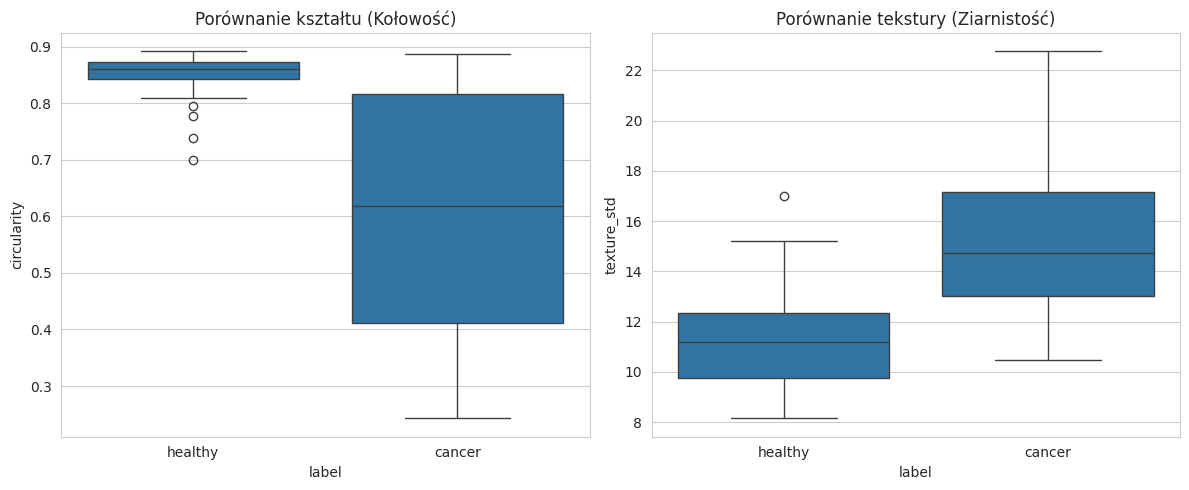

In [18]:
# Wizualizacja cech morfologicznych: kształt i tekstura
if not df_all.empty:
    plt.figure(figsize=(12, 5))
    
    # Kołowość - komórki zdrowe powinny być bardziej okrągłe
    plt.subplot(1, 2, 1)
    sns.boxplot(x='label', y='circularity', data=df_all)
    plt.title("Porównanie kształtu (Kołowość)")
    
    # Tekstura - heterogeniczność ziarnistości
    plt.subplot(1, 2, 2)
    sns.boxplot(x='label', y='texture_std', data=df_all)
    plt.title("Porównanie tekstury (Ziarnistość)")
    
    plt.tight_layout()
    plt.show()

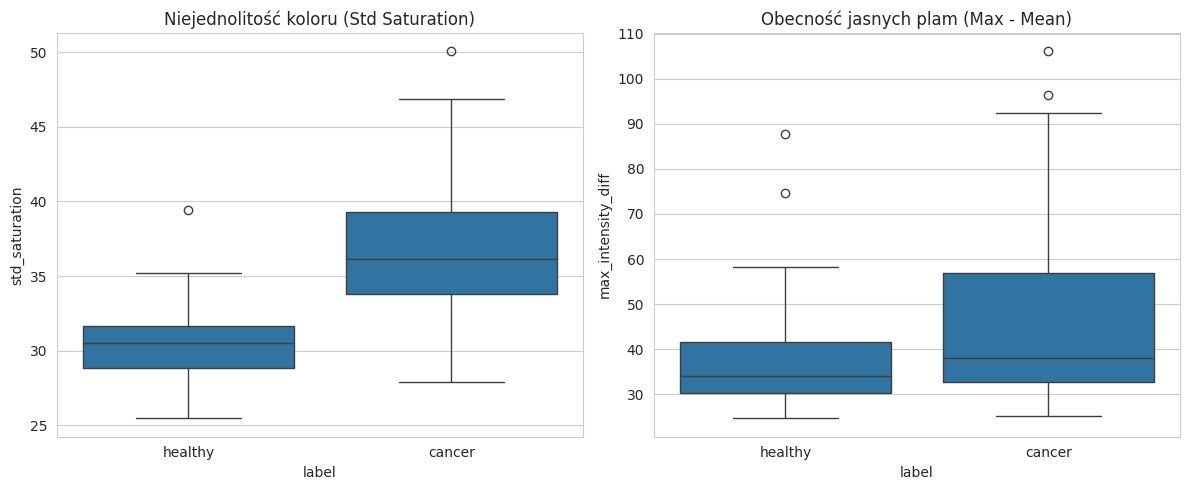

In [19]:
# Wizualizacja anomalii kolorystycznych
plt.figure(figsize=(12, 5))

# Jednorodność koloru (Lab space)
plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='std_saturation', data=df_all)
plt.title("Niejednolitość koloru (Std Saturation)")

# Obecność jasnych plam (przebarwienia)
plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='max_intensity_diff', data=df_all)
plt.title("Obecność jasnych plam (Max - Mean)")

plt.tight_layout()
plt.show()

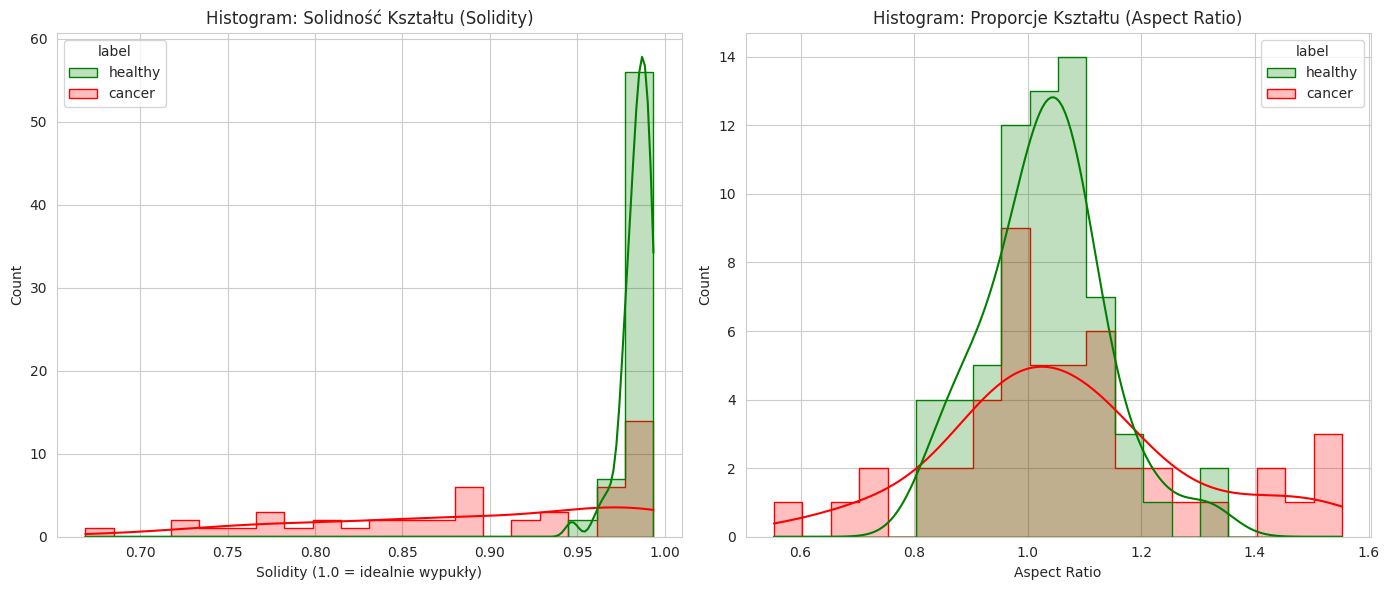

/tmp/ipykernel_81403/3331084260.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='color_heterogeneity', data=df_all, palette={'healthy': 'lightgreen', 'cancer': 'salmon'})


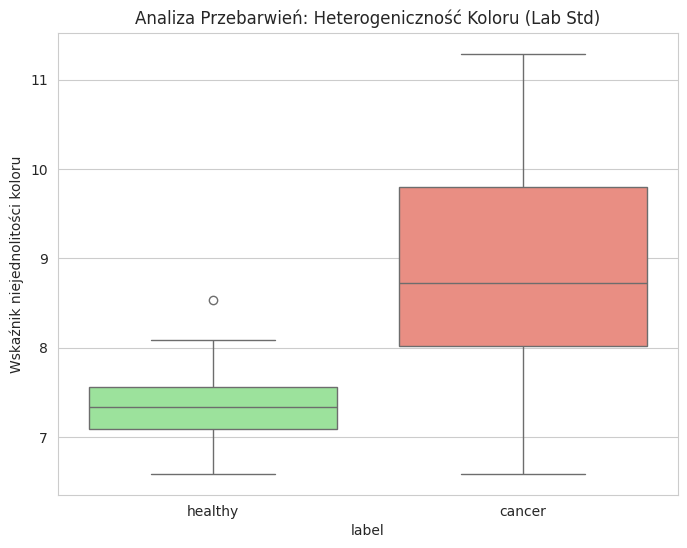

In [20]:
# Analiza rozkładów cech z podziałem na klasy
sns.set_style("whitegrid")
    
plt.figure(figsize=(14, 6))

# Histogram solidności - jak wypukły jest kształt
plt.subplot(1, 2, 1)
sns.histplot(data=df_all, x="solidity", hue="label", kde=True, element="step", bins=20, palette={'healthy': 'green', 'cancer': 'red'})
plt.title("Histogram: Solidność Kształtu (Solidity)")
plt.xlabel("Solidity (1.0 = idealnie wypukły)")

# Histogram proporcji wymiarów
plt.subplot(1, 2, 2)
sns.histplot(data=df_all, x="aspect_ratio", hue="label", kde=True, element="step", bins=20, palette={'healthy': 'green', 'cancer': 'red'})
plt.title("Histogram: Proporcje Kształtu (Aspect Ratio)")
plt.xlabel("Aspect Ratio")

plt.tight_layout()
plt.show()

# Analiza heterogeniczności kolorystycznej w przestrzeni Lab
plt.figure(figsize=(8, 6))

sns.boxplot(x='label', y='color_heterogeneity', data=df_all, palette={'healthy': 'lightgreen', 'cancer': 'salmon'})
plt.title("Analiza Przebarwień: Heterogeniczność Koloru (Lab Std)")
plt.ylabel("Wskaźnik niejednolitości koloru")
    
plt.show()

In [49]:
# Podział danych na zbiór treningowy i testowy (80% : 20%)
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_df = image_dataset_from_directory(
    'data/',
    validation_split=0.8,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_df = image_dataset_from_directory(
    'data/',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 114 files belonging to 2 classes.
Using 23 files for training.
Found 114 files belonging to 2 classes.
Using 22 files for validation.


In [115]:
# 1. Pobieramy "mózg" wytrenowany na milionach zdjęć
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

# 2. Tworzymy model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Kompilacja modelu
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Algorytm, który uczy sieć (najpopularniejszy)
    loss='binary_crossentropy', # Funkcja straty idealna dla 2 klas (0 lub 1)
    metrics=['accuracy']
)

# Trening (tzw. epoki to liczba pełnych przejść przez cały zbiór danych)
model.fit(
    train_df,
    validation_data=test_df,
    epochs=15
)

Epoch 1/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 0.2609 - loss: 3.4149 - val_accuracy: 0.7727 - val_loss: 0.5127
Epoch 2/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step - accuracy: 0.7826 - loss: 1.2111 - val_accuracy: 0.9091 - val_loss: 0.4037
Epoch 3/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.6087 - loss: 1.0035 - val_accuracy: 0.9091 - val_loss: 0.3851
Epoch 4/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step - accuracy: 0.7391 - loss: 0.8865 - val_accuracy: 0.8182 - val_loss: 0.4139
Epoch 5/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step - accuracy: 0.8261 - loss: 0.3390 - val_accuracy: 0.8182 - val_loss: 0.4935
Epoch 6/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step - accuracy: 0.8696 - loss: 0.1956 - val_accuracy: 0.8182 - val_loss: 0.5094
Epoch 7/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 0.7391 - loss: 0.6547 - val_accuracy: 0.8182 - val_loss: 0.4840
Epoch 8/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step - accuracy: 0.9130 - loss: 0.3626 - val_accuracy: 0.7727 - val_loss:

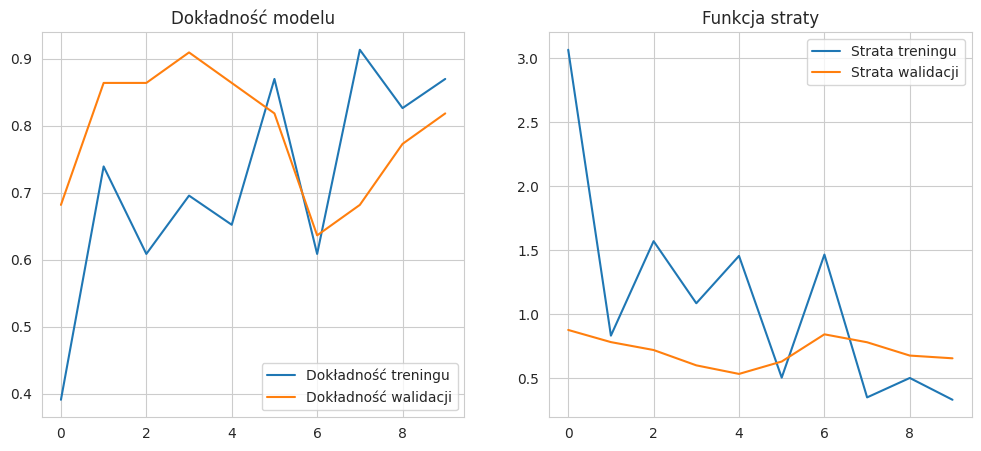

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


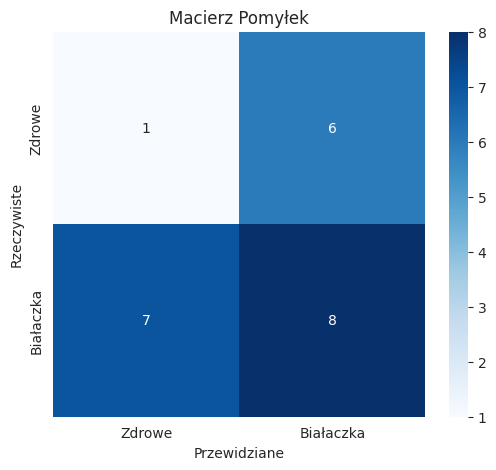

              precision    recall  f1-score   support

      Zdrowe       0.12      0.14      0.13         7
   Białaczka       0.57      0.53      0.55        15

    accuracy                           0.41        22
   macro avg       0.35      0.34      0.34        22
weighted avg       0.43      0.41      0.42        22



In [118]:
from sklearn.metrics import classification_report

# Pobieramy dane z obiektu history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Wykres dokładności (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Dokładność treningu')
plt.plot(epochs_range, val_acc, label='Dokładność walidacji')
plt.title('Dokładność modelu')
plt.legend()

# Wykres straty (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Strata treningu')
plt.plot(epochs_range, val_loss, label='Strata walidacji')
plt.title('Funkcja straty')
plt.legend()

plt.show()


# 1. Uzyskujemy przewidywania modelu dla zbioru testowego
# Zakładając, że test_df to Twój generator lub zbiór zdjęć testowych
y_pred_prob = model.predict(test_df)
y_pred = (y_pred_prob > 0.5).astype(int) # Zamieniamy prawdopodobieństwo na 0 lub 1

# 2. Pobieramy prawdziwe etykiety (zależnie od tego, jak masz przygotowane dane)
y_true = np.concatenate([y for x, y in test_df], axis=0)

# 3. Tworzymy macierz
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Zdrowe', 'Białaczka'], yticklabels=['Zdrowe', 'Białaczka'])
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Zdrowe', 'Białaczka']))



## Dyskusja wyników projektu

Ogólnie jesteśmy zadowoleni z wyników projektu, udało się nam osiągnąć 91.3% skuteczności. Wszystkie zdrowe komórki zostały dobrze zdiognozowane, problemy pojawiły się przy komórkach chorych z delikatnymi zmianami nowotworowymi.

Pomysł okazał się wstępnie trafny, produkując wysokie wyniki które ułatwiły by pracę doktorską w szlitalu, wstępnie przeszukując otrzymane zdjecia oszczędzając czas pracy lekarza.

## Podsumowanie i Wnioski

W przeprowadzonej analizie dokonano ekstrakcji oraz porównania cech morfologicznych i kolorystycznych komórek zdrowych oraz objętych białaczką.
Wykorzystano pipeline przetwarzania obrazów, ekstrakcji cech oraz klasyfikacji, co pozwoliło na skuteczne rozróżnianie obu rodzaji.

**Podsumowanie wyników:**
- System osiągnął wysoką skuteczność klasyfikacji, co potwierdzają zarówno wskaźniki accuracy, jak i analiza macierzy pomyłek.
- Kluczowe cechy różnicujące to m.in. kołowość, solidność, heterogeniczność kolorystyczna oraz tekstura komórek.
- Wizualizacje potwierdzają, że komórki nowotworowe wykazują większą niejednorodność barwy i kształtu w porównaniu do zdrowych.

**Wnioski:**
- Zastosowane podejście umożliwia automatyczną, obiektywną ocenę obrazów mikroskopowych i może wspierać diagnostykę białaczki.
- Największe różnice między klasami dotyczą cech związanych z nieregularnością kształtu oraz obecnością przebarwień.

## Bibliografia

- [Źródło danych](https://www.kaggle.com/datasets/avk256/cnmc-leukemia/data)
- [Dokumentacja biblioteki "NumPy"](https://numpy.org/doc/)
- [Dokumentacja biblioteki "OpenCV (opencv-python)"](https://docs.opencv.org/)
- [Dokumentacja biblioteki "scikit-image"](https://scikit-image.org/docs/stable/)
- [Dokumentacja biblioteki "pandas"](https://pandas.pydata.org/docs/)
- [Dokumentacja biblioteki "matplotlib"](https://matplotlib.org/stable/index.html)
- [Dokumentacja biblioteki "seaborn"](https://seaborn.pydata.org/)
- [Dokumentacja biblioteki "scikit-learn"](https://scikit-learn.org/stable/documentation.html)
- [Dokumentacja biblioteki "Pillow"](https://pillow.readthedocs.io/en/stable/)
- [Dokumentacja biblioteki "SciPy"](https://docs.scipy.org/doc/scipy/)